In [37]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict

In [38]:
class Batsmen(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    boundary_percentage: float
    six_percentage: float

    summary: str



In [39]:
def strike_rate(state:Batsmen):
    sr = (state['runs'] / state['balls']) * 100
    return {'strike_rate': sr}


def boundary_percentage(state:Batsmen):
    bp = (state['fours'] / state['balls']) * 100
    return {'boundary_percentage': bp}

def six_percentage(state:Batsmen):
    sp = (state['sixes'] / state['balls']) * 100
    return {'six_percentage': sp}

In [40]:
def summary(state:Batsmen):
    result = f"Runs: {state['runs']}, Balls: {state['balls']}, Fours: {state['fours']}, Sixes: {state['sixes']}, Strike Rate: {state['strike_rate']:.2f}, Boundary Percentage: {state['boundary_percentage']:.2f}%, Six Percentage: {state['six_percentage']:.2f}%"
    return {'summary': result}

In [41]:
graph = StateGraph(Batsmen)

graph.add_node('STRIKE_RATE', strike_rate)
graph.add_node('BOUNDARY_PERCENTAGE', boundary_percentage)
graph.add_node('SIX_PERCENTAGE', six_percentage)

graph.add_node('SUMMARY', summary)

In [42]:
graph.add_edge(START, 'STRIKE_RATE')
graph.add_edge(START, 'BOUNDARY_PERCENTAGE')
graph.add_edge(START, 'SIX_PERCENTAGE')

graph.add_edge('STRIKE_RATE', 'SUMMARY')
graph.add_edge('BOUNDARY_PERCENTAGE', 'SUMMARY')
graph.add_edge('SIX_PERCENTAGE', 'SUMMARY')

graph.add_edge('SUMMARY', END)


In [43]:
graph_build = graph.compile()

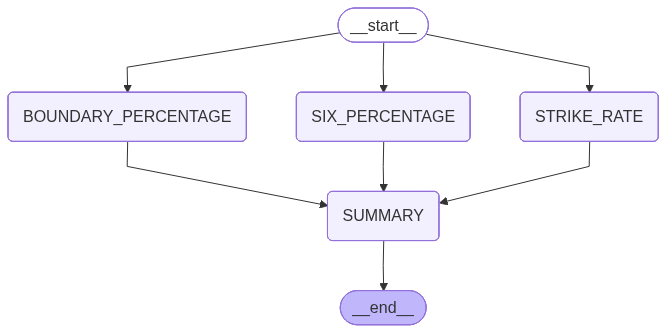

In [44]:
graph_build

In [45]:
testing_state = {
    'runs': 120,
    'balls': 80,
    'fours': 15,
    'sixes': 5
}

result = graph_build.invoke(testing_state)



In [46]:
result

{'runs': 120,
 'balls': 80,
 'fours': 15,
 'sixes': 5,
 'strike_rate': 150.0,
 'boundary_percentage': 18.75,
 'six_percentage': 6.25,
 'summary': 'Runs: 120, Balls: 80, Fours: 15, Sixes: 5, Strike Rate: 150.00, Boundary Percentage: 18.75%, Six Percentage: 6.25%'}

In [47]:
print(result['summary'])

Runs: 120, Balls: 80, Fours: 15, Sixes: 5, Strike Rate: 150.00, Boundary Percentage: 18.75%, Six Percentage: 6.25%
